# 3D-01 — NeRF from scratch : représenter une scène 3D par un réseau de neurones

[← Série GenAI/3D](README.md) | [→ Critique de NeRF (3D-02)](3D-02-NeRF-Critic.ipynb)

> **Ce que fait ce notebook** : il construit un *Neural Radiance Field* (NeRF, Mildenhall et al., ECCV 2020) entièrement from scratch en PyTorch — encodage positionnel, MLP à sauts de connexion, échantillonnage le long des rayons, rendu volumique par compositing alpha — d'abord sur une scène volumétrique synthétique dont la densité est connue en forme fermée, puis sur la scène Blender **Lego 100×100** du papier. Ce n'est **pas** un fork de `bmild/nerf` : c'est un *digest* commenté en PyTorch qui suit les équations du papier (§3, §4, §5.1) et les rend auditable ligne à ligne.
>
> **Prérequis conceptuel** : le biais spectral et les Fourier features — voir [`3.4d-Fourier-Features-Biais-Spectral-Python`](../../ML/DataScienceWithAgents/03-DeepLearning/3.4d-Fourier-Features-Biais-Spectral-Python.ipynb). Le mapping $\gamma(p)$ ci-dessous est exactement celui du Pli 1, appliqué à des coordonnées 3D.
>
> **Référence** : Mildenhall, Srinivasan, Tancik, Barron, Ramamoorthi, Ng — *NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis*, ECCV 2020, [arXiv:2003.08934](https://arxiv.org/abs/2003.08934). PDF archivé dans le gisement `G:\Mon Drive\MyIA\IA\Bibliographie IA`.

**Plan** :

1. L'idée : une fonction continue $(\mathbf{x}, \mathbf{d}) \mapsto (\sigma, \mathrm{rgb})$ au lieu d'une géométrie discrète
2. La scène jouet « Saturne » : densité analytique, vérité terrain générée par le même moteur de rendu
3. Le pipeline : encodage positionnel $\gamma$, MLP à skip-connections, rayons caméra
4. Rendu volumique from scratch : échantillonnage stratifié, compositing alpha, quadrature
5. Entraînement sur la scène jouet : courbe de perte, strip de novel views
6. Évaluation sur la scène Lego 100×100 : MSE/PSNR des novel views, compromis itérations/qualité
7. Exercices

In [1]:
import os, time, math, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

%matplotlib inline

# Reproductibilite : seeds fixes CPU et GPU
SEED = 20261008
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "| torch:", torch.__version__)

device: cuda | torch: 2.8.0+cu126


## 1. L'idée : une fonction continue au lieu d'une géométrie discrète

Les représentations 3D classiques discrétisent la scène : maillages (surfaces), voxels (grilles), nuages de points. Chacune fixe a priori une **résolution** et un **budget mémoire**. L'intuition de NeRF est de paramétrer la scène par un **réseau de neurones continu** :

$$F_\Theta : (\mathbf{x}, \mathbf{d}) \longmapsto (\sigma(\mathbf{x}),\ \mathbf{c}(\mathbf{x}, \mathbf{d}))$$

- $\mathbf{x} \in \mathbb{R}^3$ : un point de l'espace ; $\sigma(\mathbf{x}) \geq 0$ : la **densité volumique** (opacité locale, la probabilité qu'un photon s'arrête par unité de longueur) ;
- $\mathbf{d} \in \mathbb{S}^2$ : la direction d'observation ; $\mathbf{c}$ : la couleur radiée, qui dépend de la direction (réflexion spéculaire) ;
- le réseau est entraîné **par scène**, uniquement par rétropropagation depuis des **images 2D connues** (une dizaine à une centaine de photos calibrées) : aucune supervision 3D directe.

Deux gestes rendent l'approche praticable, tous deux hérités du Pli 1 :

1. **l'encodage positionnel** $\gamma(\mathbf{x})$ : un MLP standard est sujet au *biais spectral* — il apprend d'abord les basses fréquences. Mapper l'entrée dans une base de sinusoïdes bande-largies $\{2^0\pi, \dots, 2^{L-1}\pi\}$ permet au réseau de représenter des variations rapides de la densité ;
2. **le rendu volumique différentiable** : l'équation de rendu le long d'un rayon est approchée par une somme finie (quadrature) dont chaque terme est différentiable — la perte 2D remonte jusqu'aux poids du MLP.

## 2. La scène jouet « Saturne » : une densité analytique

Avant la scène Blender, on travaille sur une scène **volumétrique synthétique** dont la densité $\sigma(\mathbf{x})$ et la couleur sont connues en forme fermée : une sphère chaude traversée par un anneau incliné. Deux avantages pédagogiques :

- la **vérité terrain 3D existe** : on pourra trancher le réseau appris et le comparer à la vraie densité (§5) ;
- le **moteur de rendu** qui génère les images de référence est *exactement celui* qui servira à rendre le NeRF — la seule inconnue du problème d'apprentissage est la fonction $\sigma$, pas le pipeline caméra.

Les bords sont adoucis par des sigmoïdes (largeur `w`) : des bords raides contiennent des fréquences spatiales très hautes, pénibles pour l'optimisation. En revanche la sphère porte une **face en échiquier** (cases de 0,25 unité) et l'anneau des **stries concentriques** : ce contenu haute fréquence est délibéré — c'est lui qui donnera du travail à l'encodage positionnel $\gamma$ (§3) et le matière aux limitations mesurées de [3D-02](3D-02-NeRF-Critic.ipynb).

In [2]:
# Scene volumetrique jouet : sphere + anneau incline, densites et couleurs analytiques.
# Conventions : axes (x, y, z), y vertical. Les couleurs dependent de la position.

def sigma_couleur_sphere(x, y, z):
    # Sphere dense de rayon 1.0, chaude (rouge-or), face en echiquier (haute frequence
    # de taille 0.25 unites : le contenu spectral qui justifie l'encodage positionnel).
    r = torch.sqrt(x*x + y*y + z*z)
    bord = torch.sigmoid((1.0 - r) / 0.04)          # 1 a l'interieur, 0 a l'exterieur
    sigma = 60.0 * bord
    damier = (torch.floor(4.0 * x) + torch.floor(4.0 * z)) % 2.0    # 0 ou 1, cases de 0.25
    rgb = torch.stack([0.86 + 0.08*y, 0.42 - 0.10*y, 0.24 + 0.12*y], dim=-1)
    rgb = rgb * (0.55 + 0.45 * damier)[..., None]
    return sigma, rgb

def sigma_couleur_anneau(x, y, z):
    # Anneau plan incline de 20 deg autour de l'axe x, rayon interne 1.45, externe 2.1.
    a = math.radians(20.0)
    y2 = y*math.cos(a) + z*math.sin(a)              # rotation inverse : plan de l'anneau
    z2 = -y*math.sin(a) + z*math.cos(a)
    rho = torch.sqrt(x*x + z2*z2)
    radial = torch.sigmoid((rho - 1.45)/0.05) * torch.sigmoid((2.1 - rho)/0.05)
    epaisseur = torch.sigmoid((0.08 - torch.abs(y2))/0.03)
    stries = 0.75 + 0.25*torch.cos(24.0*rho)        # stries concentriques (haute frequence douce)
    sigma = 34.0 * radial * epaisseur * stries
    bleu = (rho - 1.45) / 0.65
    rgb = torch.stack([0.55 - 0.20*bleu, 0.60 - 0.10*bleu, 0.78 + 0.10*bleu], dim=-1)
    return sigma, rgb

def scene_jouet(x, y, z):
    # Densite + couleur de la scene complete (superposition additive des deux corps).
    s1, c1 = sigma_couleur_sphere(x, y, z)
    s2, c2 = sigma_couleur_anneau(x, y, z)
    tot = s1 + s2 + 1e-10
    sigma = s1 + s2
    rgb = (s1[..., None]*c1 + s2[..., None]*c2) / tot[..., None]   # moyenne ponderee par la densite
    return sigma, rgb

In [3]:
# Poses camera spheriques (convention c2w OpenGL, z vers l'arriere, comme tiny_nerf).

def pose_spherique(theta_deg, phi_deg, rayon):
    # Matrice c2w d'une camera placee en coordonnees spheriques (angles en degres).
    def trans_t(t):
        return np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, t],
                         [0, 0, 0, 1]], dtype=np.float32)
    def rot_phi(phi):
        return np.array([[1, 0, 0, 0],
                         [0, math.cos(phi), -math.sin(phi), 0],
                         [0, math.sin(phi),  math.cos(phi), 0],
                         [0, 0, 0, 1]], dtype=np.float32)
    def rot_theta(th):
        return np.array([[math.cos(th), 0, -math.sin(th), 0],
                         [0, 1, 0, 0],
                         [math.sin(th), 0,  math.cos(th), 0],
                         [0, 0, 0, 1]], dtype=np.float32)
    c2w = rot_theta(math.radians(theta_deg)) @ rot_phi(math.radians(phi_deg)) @ trans_t(rayon)
    # Passage au repere OpenGL (y vers le haut, z vers l'arriere de la camera)
    return np.array([[-1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0],
                     [0, 0, 0, 1]], dtype=np.float32) @ c2w

N_VUES_JOUET, RES_JOUET, FOCAL_JOUET = 40, 64, 70.0
NEAR, FAR = 2.0, 6.0
poses_jouet = torch.tensor(np.stack([
    pose_spherique(t, -12.0, 4.0) for t in np.linspace(0, 360, N_VUES_JOUET, endpoint=False)
]))
# Vue test : un angle intercale, jamais vue a l'entrainement
pose_test_jouet = torch.tensor(pose_spherique(181.0, -12.0, 4.0))
print("poses jouet :", poses_jouet.shape, "| resolution :", RES_JOUET, "| focal :", FOCAL_JOUET)

poses jouet : torch.Size([40, 4, 4]) | resolution : 64 | focal : 70.0


## 3. Le pipeline : encodage positionnel, MLP, rayons caméra

### 3.1 L'encodage positionnel $\gamma$

L'identité clé du Pli 1 : un kernel tangent de bande passante étroite condamne le MLP brut aux basses fréquences. NeRF applique à chaque coordonnée le mapping sinusoidal du papier (§5.1, éq. 4) :

$$\gamma(p) = \big(p,\ \sin(2^0\pi p), \cos(2^0\pi p),\ \dots,\ \sin(2^{L-1}\pi p), \cos(2^{L-1}\pi p)\big)$$

Le papier utilise $L=10$ pour la position $\mathbf{x}$ et $L=4$ pour la direction $\mathbf{d}$ (les directions varient lentement — la couleur spéculaire est un phénomène plus lisse que la géométrie).

In [4]:
def gamma(p, L):
    # Encodage positionnel du papier NeRF (eq. 4) : [p, sin(2^k pi p), cos(2^k pi p)] pour k < L.
    freqs = 2.0 ** torch.arange(L, device=p.device) * math.pi
    angles = p[..., None] * freqs          # (..., 3, L)
    return torch.cat([p, torch.sin(angles).flatten(-2), torch.cos(angles).flatten(-2)], dim=-1)

L_X, L_D = 10, 4
print("dim gamma(x) avec L=10 :", 3 + 2 * 3 * 10, "| dim gamma(d) avec L=4 :", 3 + 2 * 3 * 4)

dim gamma(x) avec L=10 : 63 | dim gamma(d) avec L=4 : 27


### 3.2 Le MLP à skip-connections (papier §5.1, figure 7)

Huit couches de 256 unités pour la densité (entrée $\gamma(\mathbf{x})$, 63 dimensions — la largeur du papier, §5.1), avec une **connexion sautée** qui réinjecte $\gamma(\mathbf{x})$ à mi-tronc — le papier montre que ce raccourci améliore la propagation de gradient vers les premières couches. La couleur est produite par une tête séparée qui consomme $\gamma(\mathbf{d})$ et la feature intermédiaire. La section 6 (données réelles Lego) utilisera la largeur 128 du `tiny_nerf` de référence, avec son régime d'entraînement.

In [5]:
class NeRF(nn.Module):
    # MLP du papier : 8 couches x 256 (largeur du papier, section 5.1) + tete
    # couleur sur gamma(d). La section 6 (Lego) utilise la largeur 128 du
    # tiny_nerf de reference avec son regime d'entrainement canonique.
    def __init__(self, hidden=256, L_x=L_X, L_d=L_D):
        super().__init__()
        self.in_x, self.in_d = 3 + 2 * 3 * L_x, 3 + 2 * 3 * L_d
        self.entree_x = nn.Linear(self.in_x, hidden)             # gamma(x) -> h
        self.tronc1 = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(4)])
        self.saut = nn.Linear(hidden + self.in_x, hidden)        # apres concatenation du saut
        self.tronc2 = nn.ModuleList([nn.Linear(hidden, hidden) for _ in range(3)])
        self.sigma = nn.Linear(hidden, 1)
        self.tete_feat = nn.Linear(hidden + self.in_d, hidden // 2)
        self.rgb = nn.Linear(hidden // 2, 3)
        # Biais initial positif sur la tete sigma : a l'init par defaut, le tronc
        # ReLU profond demarre avec des activations minuscules et la pre-activation
        # sigma est negative partout (mesure : max -0.036) -> ReLU mort, sigma = 0
        # definitivement, rendu noir, aucun gradient. Le biais > 0 demarre le champ
        # legerement opaque et laisse le gradient circuler des l'iter 1. Sur la
        # scene jouet il suffit ; sur Lego, la section 6 le combine au regime
        # canonique tiny_nerf (largeur 128, 4096 rayons/pas, lr quasi plat),
        # mesure stable quel que soit L (L in {0, 4, 10}).
        nn.init.constant_(self.sigma.bias, 0.1)

    def forward(self, gx, gd):
        h = torch.relu(self.entree_x(gx))
        for lin in self.tronc1:
            h = torch.relu(lin(h))
        h = torch.relu(self.saut(torch.cat([h, gx], dim=-1)))    # reinjection de gamma(x)
        for lin in self.tronc2:
            h = torch.relu(lin(h))
        sigma = torch.relu(self.sigma(h))
        h = torch.relu(self.tete_feat(torch.cat([h, gd], dim=-1)))
        rgb = torch.sigmoid(self.rgb(h))
        return rgb, sigma

In [6]:
# Test de forme : un batch de points et de directions doit rendre (B, 3) et (B, 1).
modele_test = NeRF().to(DEVICE)
with torch.no_grad():
    _pts = torch.rand(1024, 3, device=DEVICE) * 4 - 2
    _dir = torch.nn.functional.normalize(torch.rand(1024, 3, device=DEVICE), dim=-1)
    _rgb, _sig = modele_test(gamma(_pts, L_X), gamma(_dir, L_D))
print("sorties : rgb", tuple(_rgb.shape), "| sigma", tuple(_sig.shape))
del _pts, _dir, _rgb, _sig, modele_test
print("NeRF : nombre de parametres =", sum(p.numel() for p in NeRF().parameters()))

sorties : rgb (1024, 3) | sigma (1024, 1)
NeRF : nombre de parametres = 595844


### 3.3 Les rayons caméra

Pour chaque pixel $(i, j)$ d'une image $H \times W$ avec focale $f$ (repère OpenGL : $x$ vers la droite, $y$ vers le haut, $z$ vers l'arrière), la direction en repère caméra est $\big(\frac{i - W/2}{f},\ -\frac{j - H/2}{f},\ -1\big)$ ; la rotation $R$ de la pose c2w l'exprime dans le monde, et l'origine est la translation $t$ de la pose.

In [7]:
def get_rays(H, W, focal, c2w):
    # Origines et directions de rayon pour chaque pixel d'une camera c2w (convention OpenGL).
    i, j = torch.meshgrid(torch.arange(W, dtype=torch.float32, device=c2w.device),
                          torch.arange(H, dtype=torch.float32, device=c2w.device),
                          indexing="xy")
    dirs_cam = torch.stack([(i - W / 2) / focal,
                            -(j - H / 2) / focal,
                            -torch.ones_like(i)], dim=-1)             # (H, W, 3)
    rays_d = torch.sum(dirs_cam[..., None, :] * c2w[:3, :3], dim=-1)  # rotation vers le monde
    rays_o = c2w[:3, -1].expand(rays_d.shape)                         # origine = translation
    return rays_o.reshape(-1, 3), rays_d.reshape(-1, 3)               # (H*W, 3)

## 4. Rendu volumique from scratch

### 4.1 Échantillonnage stratifié

On tire $N$ profondeurs $t_i$ uniformes dans $[t_\mathrm{near}, t_\mathrm{far}]$ **par rayon**, avec un jitter stratifié — le papier montre (fig. 12) que ce jitter agit comme un **anti-aliasing stochastique** : il régularise l'apprentissage face aux fréquences que l'échantillonnage régulier rate. Les points échantillonnés sont $\mathbf{x}_i = \mathbf{o} + t_i \mathbf{d}$.

### 4.2 Compositing alpha (quadrature de l'équation de rendu)

La couleur le long du rayon $C = \int T(t)\,\sigma(t)\,\mathbf{c}(t)\,dt$ avec transmittance $T(t) = \exp(-\int_0^t \sigma(s)ds)$ s'approche par (papier §4, éq. 1-3) :

$$\hat{C} = \sum_{i=1}^{N} w_i\, \mathbf{c}_i, \qquad w_i = \alpha_i \prod_{j<i} (1 - \alpha_j), \qquad \alpha_i = 1 - \exp(-\sigma_i\,\delta_i)$$

où $\delta_i = t_{i+1} - t_i$ est la distance entre échantillons voisins (le dernier segment est fermé à l'infini : le rayon s'échappe). Les poids $w_i$ (qui somment à 1) forment un **histogramme de profondeur** : leur espérance $\sum_i w_i t_i$ est la carte de profondeur.

In [8]:
def sample_stratifie(rays_o, rays_d, n_samples, near, far, jitter=True):
    # Profondeurs t_i uniformes (+ jitter) et points x_i = o + t d pour chaque rayon.
    t = torch.linspace(near, far, n_samples, device=rays_o.device)             # (N,)
    t = t.expand(rays_o.shape[0], n_samples)                                   # (B, N)
    if jitter:
        ecart = (far - near) / n_samples
        t = t + torch.rand_like(t) * ecart
    pts = rays_o[:, None, :] + rays_d[:, None, :] * t[..., None]               # (B, N, 3)
    return pts, t

def rendu_volumique(rgb, sigma, t):
    # Compositing alpha : couleur, poids et profondeur attendue par rayon (eq. 1-3 du papier).
    delta = t[:, 1:] - t[:, :-1]
    delta = torch.cat([delta, torch.full_like(delta[:, :1], 1e9)], dim=-1)     # dernier segment -> infini
    alpha = 1.0 - torch.exp(-torch.relu(sigma[..., 0]) * delta)
    poids = alpha * torch.cumprod(
        torch.cat([torch.ones_like(alpha[:, :1]), 1.0 - alpha + 1e-10], dim=-1),
        dim=-1)[:, :-1]
    couleur = torch.sum(poids[..., None] * rgb, dim=-2)
    profondeur = torch.sum(poids * t, dim=-1)
    return couleur, poids, profondeur

In [9]:
def rendu_nerf(modele, rays_o, rays_d, n_samples, near, far, chunk=4096):
    # Rendu complet : echantillonnage -> gamma(x), gamma(d) -> MLP -> compositing.
    # chunk : bornage memoire, les rayons sont traites par lots de points.
    couleurs, profondeurs = [], []
    for o, d in zip(rays_o.split(chunk), rays_d.split(chunk)):
        pts, t = sample_stratifie(o, d, n_samples, near, far)
        d_norm = torch.nn.functional.normalize(d, dim=-1)
        gx = gamma(pts, L_X)
        gd = gamma(d_norm[:, None, :].expand_as(pts), L_D)
        rgb, sigma = modele(gx, gd)
        c, _, prof = rendu_volumique(rgb, sigma, t)
        couleurs.append(c)
        profondeurs.append(prof)
    return torch.cat(couleurs), torch.cat(profondeurs)

def generer_image_verite(c2w, H, W, focal, n_samples=128):
    # Verite terrain de la scene jouet : le MEME rendu volumique, la densite analytique a la place du MLP.
    rays_o, rays_d = get_rays(H, W, focal, c2w.to(DEVICE))
    pts, t = sample_stratifie(rays_o, rays_d, n_samples, NEAR, FAR)
    with torch.no_grad():
        sigma, rgb = scene_jouet(pts[..., 0], pts[..., 1], pts[..., 2])
        c, _, prof = rendu_volumique(rgb, sigma[..., None], t)
    return c.reshape(H, W, 3), prof.reshape(H, W)

dataset jouet : (40, 64, 64, 3) genere en 0.2s sur cuda (min -0.009, max 1.037)


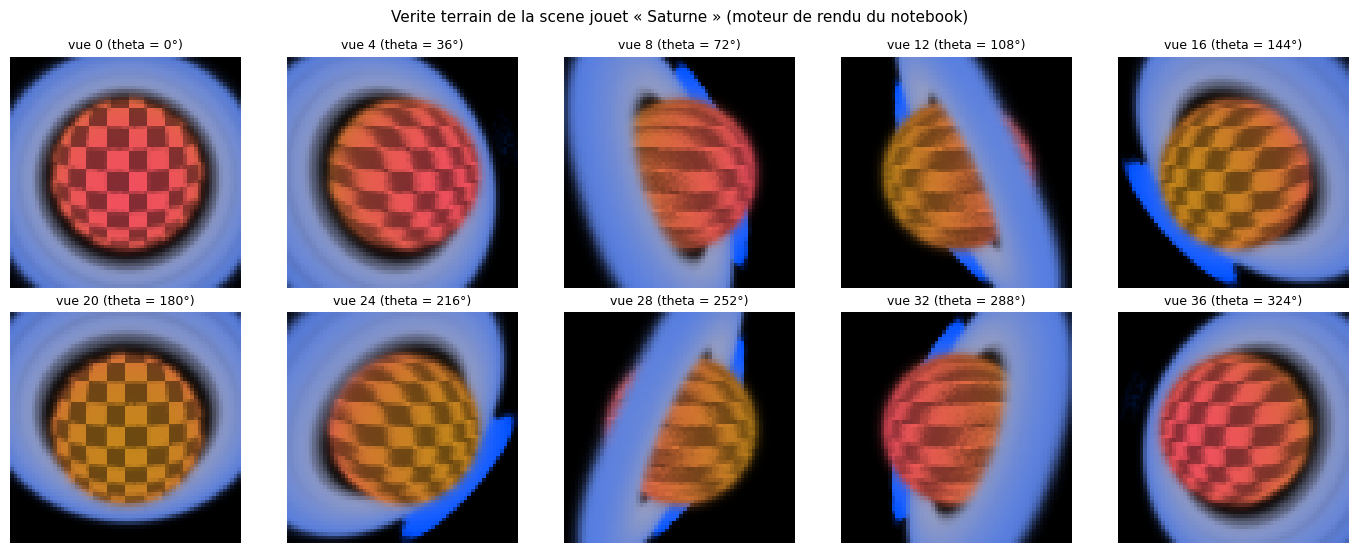

In [10]:
# Generation du dataset jouet : 40 vues de reference + la vue test, et visualisation.
t0 = time.time()
with torch.no_grad():
    images_jouet = torch.stack([generer_image_verite(p, RES_JOUET, RES_JOUET, FOCAL_JOUET)[0]
                                for p in poses_jouet])
    image_test_jouet, profondeur_test_jouet = generer_image_verite(
        pose_test_jouet, RES_JOUET, RES_JOUET, FOCAL_JOUET)
print(f"dataset jouet : {tuple(images_jouet.shape)} genere en {time.time()-t0:.1f}s "
      f"sur {DEVICE} (min {images_jouet.min():.3f}, max {images_jouet.max():.3f})")

fig, axes = plt.subplots(2, 5, figsize=(14, 5.6))
for k, ax in enumerate(axes.flat):
    ax.imshow(images_jouet[4 * k].clamp(0, 1).cpu().numpy())
    ax.set_title(f"vue {4*k} (theta = {4*k*9}\N{DEGREE SIGN})", fontsize=9)
    ax.axis("off")
fig.suptitle("Verite terrain de la scene jouet \u00ab Saturne \u00bb (moteur de rendu du notebook)", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Entraînement sur la scène jouet

Boucle du papier (§5.2), version *tiny* : à chaque itération on tire **une image au hasard** et, dedans, **un minibatch de 2 048 rayons** (le papier échantillonne de même un lot de rayons par pas, §5.2 : *a random set of rays* ; la section 6 montera à 4 096, la taille du `tiny_nerf` de référence) ; la perte est le MSE des couleurs rendues contre la vérité terrain ; Adam avec la décroissance exponentielle du papier — ici le palier est calé sur 4 605 itérations (facteur 0,9995 par pas, adapté au budget court de la scène jouet) ; la section 6 le calera sur la durée du papier (250 000), quasi plate à l'échelle *tiny*. Pas de réseau coarse-to-fine hiérarchique — le papier (§5.1) n'utilise ce second échantillonnage que pour ré-allouer les échantillons là où le réseau *coarse* prévoit de la densité ; à cette résolution avec 48 échantillons stratifiés, l'échantillonnage uniforme suffit à converger (c'est aussi le choix de `tiny_nerf`).

In [11]:
def entrainer_nerf(modele, images, poses, n_train, image_test, pose_test, H, W, focal,
                   n_iters, n_samples, near, far, n_rayons=2048,
                   lr0=5e-4, decay_palier=4605, log_every=200):
    # Boucle du papier (version tiny) : 1 image tiree au hasard, n_rayons rayons tires dedans.
    # Decroissance du papier : lr0 * 0.1 ** (it / decay_palier). Palier jouet
    # 4605 (= facteur 0.9995/pas) ; la section Lego passe 250000 + 4096 rayons
    # (regime canonique du tiny_nerf de reference).
    optim = torch.optim.Adam(modele.parameters(), lr=lr0)
    historique, strip = [], []
    rays_test_o, rays_test_d = get_rays(H, W, focal, pose_test.to(DEVICE))
    cible_test = image_test.to(DEVICE).reshape(-1, 3)
    t0 = time.time()
    for it in range(1, n_iters + 1):
        optim.param_groups[0]["lr"] = lr0 * 0.1 ** (it / decay_palier)
        k = np.random.randint(n_train)
        rays_o, rays_d = get_rays(H, W, focal, poses[k].to(DEVICE))
        sel = torch.randint(0, rays_o.shape[0], (n_rayons,), device=DEVICE)
        rgb, _ = rendu_nerf(modele, rays_o[sel], rays_d[sel], n_samples, near, far)
        perte = torch.mean((rgb - images[k].to(DEVICE).reshape(-1, 3)[sel]) ** 2)
        optim.zero_grad(); perte.backward(); optim.step()
        historique.append(perte.item())
        if it % log_every == 0 or it == 1:
            with torch.no_grad():
                rgb_test, _ = rendu_nerf(modele, rays_test_o, rays_test_d, n_samples, near, far)
                mse = torch.mean((rgb_test - cible_test) ** 2).item()
            strip.append((it, rgb_test.reshape(H, W, 3).clamp(0, 1).cpu().numpy()))
            print(f"iter {it:4d} | perte train {perte.item():.5f} | "
                  f"MSE vue test {mse:.5f} | PSNR {(-10*math.log10(mse)):.2f} dB "
                  f"| {it/(time.time()-t0):.1f} it/s")
    return historique, strip

In [12]:
N_ITERS_JOUET, N_SAMPLES_JOUET = 1000, 48
modele_jouet = NeRF().to(DEVICE)
historique, strip = entrainer_nerf(modele_jouet, images_jouet, poses_jouet, N_VUES_JOUET,
                                   image_test_jouet, pose_test_jouet,
                                   RES_JOUET, RES_JOUET, FOCAL_JOUET,
                                   N_ITERS_JOUET, N_SAMPLES_JOUET, NEAR, FAR)

iter    1 | perte train 0.12805 | MSE vue test 0.07840 | PSNR 11.06 dB | 5.5 it/s


iter  200 | perte train 0.05918 | MSE vue test 0.05801 | PSNR 12.37 dB | 27.5 it/s


iter  400 | perte train 0.04928 | MSE vue test 0.04641 | PSNR 13.33 dB | 27.9 it/s


iter  600 | perte train 0.01958 | MSE vue test 0.02363 | PSNR 16.27 dB | 28.0 it/s


iter  800 | perte train 0.01887 | MSE vue test 0.01243 | PSNR 19.06 dB | 28.2 it/s


iter 1000 | perte train 0.00945 | MSE vue test 0.00764 | PSNR 21.17 dB | 28.3 it/s


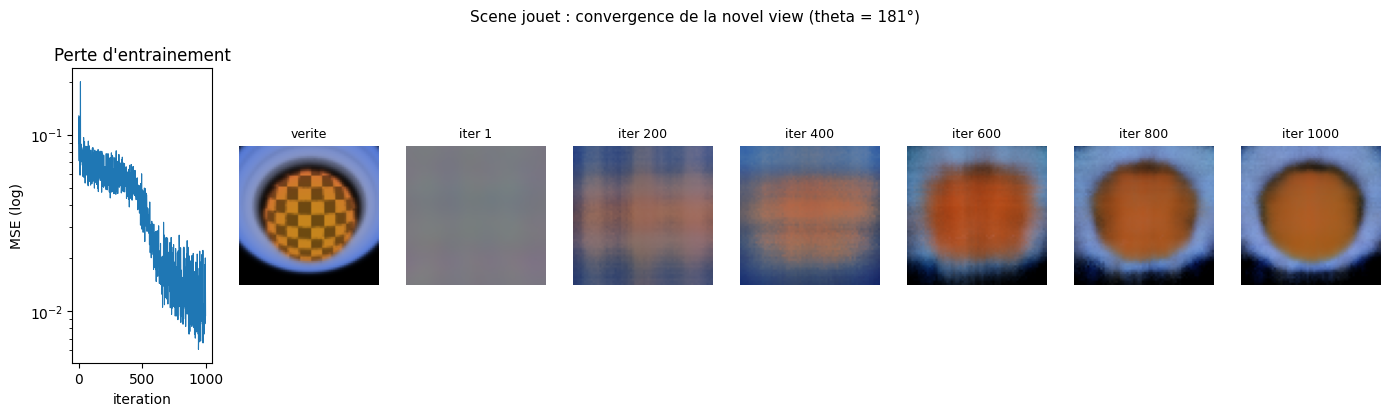

In [13]:
# Courbe de perte + strip de progression de la vue test (novel view jamais vue).
fig = plt.figure(figsize=(14, 4.2))
ax1 = fig.add_subplot(1, len(strip) + 2, 1)
ax1.plot(historique, lw=0.8)
ax1.set_yscale("log"); ax1.set_xlabel("iteration"); ax1.set_ylabel("MSE (log)")
ax1.set_title("Perte d'entrainement")
ax2 = fig.add_subplot(1, len(strip) + 2, 2)
ax2.imshow(image_test_jouet.clamp(0, 1).cpu().numpy()); ax2.set_title("verite", fontsize=9)
ax2.axis("off")
for k, (it, img) in enumerate(strip):
    ax = fig.add_subplot(1, len(strip) + 2, 3 + k)
    ax.imshow(img); ax.set_title(f"iter {it}", fontsize=9); ax.axis("off")
fig.suptitle("Scene jouet : convergence de la novel view (theta = 181\N{DEGREE SIGN})", fontsize=11)
plt.tight_layout()
plt.show()

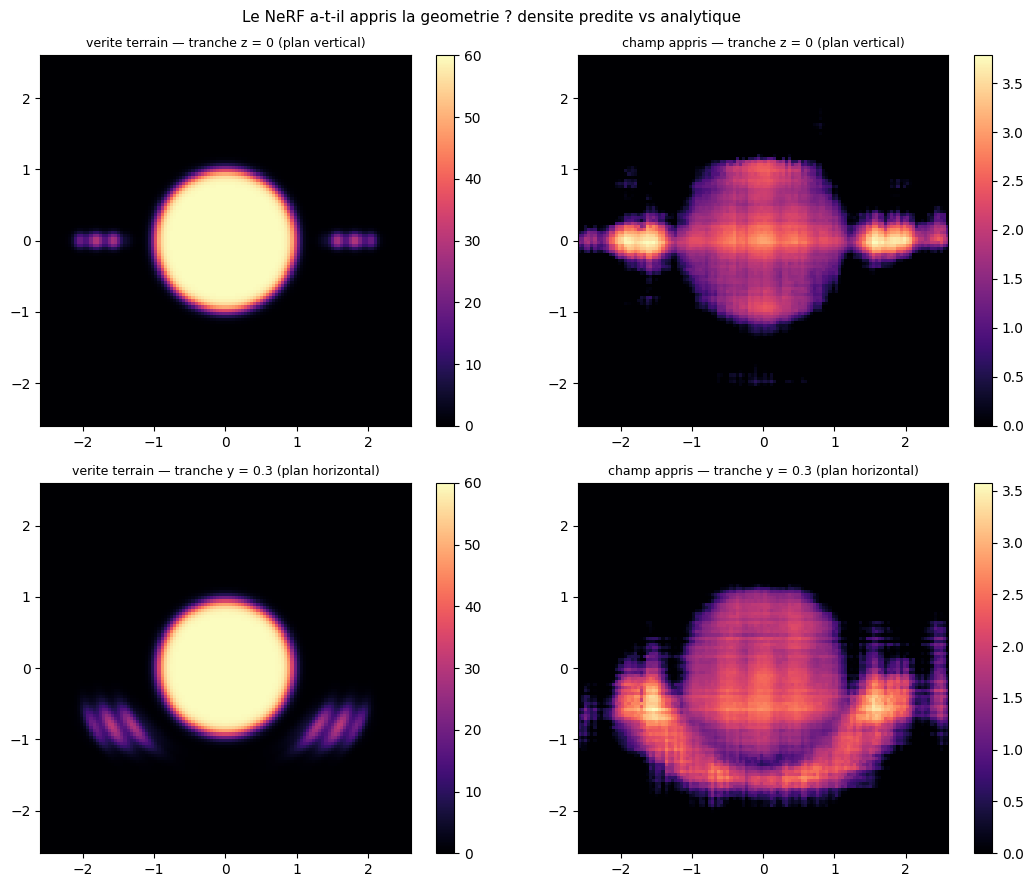

In [14]:
# Auditer le champ appris : tranches de densite predite vs densite analytique.
BORNE, N_GRILLE = 2.6, 120
grille = torch.linspace(-BORNE, BORNE, N_GRILLE, device=DEVICE)

def tranche(axe, v):
    # Points de la tranche (axe fixe a v) + densites analytique et predite cote a cote.
    a, b = torch.meshgrid(grille, grille, indexing="ij")
    if axe == "z":
        pts = torch.stack([a.reshape(-1), b.reshape(-1),
                           torch.full_like(a.reshape(-1), v)], dim=-1)
    else:
        pts = torch.stack([a.reshape(-1), torch.full_like(a.reshape(-1), v),
                           b.reshape(-1)], dim=-1)
    with torch.no_grad():
        s_vrai, _ = scene_jouet(pts[:, 0], pts[:, 1], pts[:, 2])
        _, s_pred = modele_jouet(gamma(pts, L_X),
                                 gamma(torch.nn.functional.normalize(pts, dim=-1), L_D))
    return (s_vrai.reshape(N_GRILLE, N_GRILLE).cpu().numpy(),
            s_pred.reshape(N_GRILLE, N_GRILLE).cpu().numpy())

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for k, (axe, v, lab) in enumerate([("z", 0.0, "tranche z = 0 (plan vertical)"),
                                   ("y", 0.3, "tranche y = 0.3 (plan horizontal)")]):
    vrai, pred = tranche(axe, v)
    for j, (img, t) in enumerate([(vrai, "verite terrain"), (pred, "champ appris")]):
        im = axes[k][j].imshow(img.T, origin="lower",
                               extent=[-BORNE, BORNE, -BORNE, BORNE], cmap="magma")
        axes[k][j].set_title(f"{t} \u2014 {lab}", fontsize=9)
        fig.colorbar(im, ax=axes[k][j], fraction=0.046)
fig.suptitle("Le NeRF a-t-il appris la geometrie ? densite predite vs analytique", fontsize=11)
plt.tight_layout()
plt.show()

## 6. Évaluation sur la scène Blender Lego 100×100

Le dataset officiel `tiny_nerf_data.npz` (hébergé par les auteurs, UCSD) : **106 vues** de la scène Blender « Lego bulldozer » à 100×100, avec poses c2w calibrées et focale. C'est le protocole du papier en version basse résolution — mêmes poses hémisphériques, même convention OpenGL.

On garde les 100 premières vues pour l'entraînement et la vue **101** pour le test (novel view jamais vue pendant l'entraînement), et on mesure le compromis **itérations / qualité** : MSE et PSNR $= -10\log_{10}(\mathrm{MSE})$ sur la vue test aux paliers enregistrés. On adopte le **régime d'entraînement du `tiny_nerf` de référence** — largeur 128, 4 096 rayons par pas, décroissance calée sur la durée du papier (quasi plate à 2 000 itérations) — mesuré stable sur ces données.

In [15]:
# Telechargement (mis en cache dans data/, hors depot) : dataset officiel des auteurs.
URL_LEGO = "https://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz"
CHEMIN_LEGO = os.path.join("data", "tiny_nerf_data.npz")
if not os.path.exists(CHEMIN_LEGO):
    os.makedirs("data", exist_ok=True)
    print("telechargement de", URL_LEGO)
    urllib.request.urlretrieve(URL_LEGO, CHEMIN_LEGO)
d = np.load(CHEMIN_LEGO)
images_lego = torch.tensor(d["images"]).float()          # (106, 100, 100, 3) dans [0, 1]
poses_lego = torch.tensor(d["poses"]).float()            # (106, 4, 4) c2w
FOCAL_LEGO = float(d["focal"])
print("Lego :", tuple(images_lego.shape), "| focal :", round(FOCAL_LEGO, 2),
      "| vmin/vmax :", images_lego.min().item(), images_lego.max().item())

telechargement de https://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz


Lego : (106, 100, 100, 3) | focal : 138.89 | vmin/vmax : 0.0 1.0


In [16]:
N_ITERS_LEGO, N_SAMPLES_LEGO = 2000, 64
modele_lego = NeRF(hidden=128).to(DEVICE)   # largeur du tiny_nerf de reference
historique_lego, strip_lego = entrainer_nerf(
    modele_lego, images_lego, poses_lego, 100,
    images_lego[101], poses_lego[101],
    100, 100, FOCAL_LEGO, N_ITERS_LEGO, N_SAMPLES_LEGO, 2.0, 6.0,
    n_rayons=4096, decay_palier=250000)     # regime canonique tiny_nerf

iter    1 | perte train 0.18142 | MSE vue test 0.17804 | PSNR 7.49 dB | 0.5 it/s


iter  200 | perte train 0.03156 | MSE vue test 0.07928 | PSNR 11.01 dB | 20.5 it/s


iter  400 | perte train 0.01584 | MSE vue test 0.03046 | PSNR 15.16 dB | 22.5 it/s


iter  600 | perte train 0.00950 | MSE vue test 0.01283 | PSNR 18.92 dB | 23.3 it/s


iter  800 | perte train 0.01107 | MSE vue test 0.01009 | PSNR 19.96 dB | 23.8 it/s


...

iter 1200 | perte train 0.00606 | MSE vue test 0.00902 | PSNR 20.45 dB | 24.3 it/s


iter 1400 | perte train 0.00361 | MSE vue test 0.00814 | PSNR 20.89 dB | 24.5 it/s


iter 1600 | perte train 0.00666 | MSE vue test 0.00771 | PSNR 21.13 dB | 24.6 it/s


iter 1800 | perte train 0.00819 | MSE vue test 0.00648 | PSNR 21.89 dB | 24.7 it/s


iter 2000 | perte train 0.00408 | MSE vue test 0.00653 | PSNR 21.85 dB | 24.7 it/s


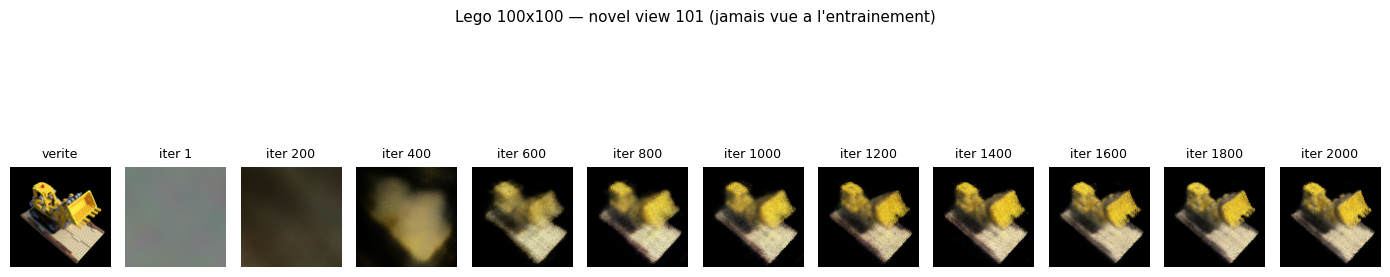

|  palier   |    MSE    | PSNR (dB) |
| iter 1    |   0.17804 |      7.49 |
| iter 200  |   0.07928 |     11.01 |
| iter 400  |   0.03046 |     15.16 |
| iter 600  |   0.01283 |     18.92 |
| iter 800  |   0.01009 |     19.96 |
| iter 1000 |   0.00967 |     20.15 |
| iter 1200 |   0.00902 |     20.45 |
| iter 1400 |   0.00814 |     20.89 |
| iter 1600 |   0.00771 |     21.13 |
| iter 1800 |   0.00648 |     21.89 |
| iter 2000 |   0.00653 |     21.85 |


In [17]:
# Compromis iterations / qualite : la vue test aux paliers enregistres + tableau MSE/PSNR.
fig = plt.figure(figsize=(14, 4.0))
ax = fig.add_subplot(1, len(strip_lego) + 1, 1)
ax.imshow(images_lego[101].clamp(0, 1).numpy()); ax.set_title("verite", fontsize=9)
ax.axis("off")
for k, (it, img) in enumerate(strip_lego):
    ax = fig.add_subplot(1, len(strip_lego) + 1, 2 + k)
    ax.imshow(img); ax.set_title(f"iter {it}", fontsize=9); ax.axis("off")
fig.suptitle("Lego 100x100 \u2014 novel view 101 (jamais vue a l'entrainement)", fontsize=11)
plt.tight_layout(); plt.show()

# Mesure quantitative : MSE/PSNR de chaque palier du strip contre la verite terrain.
cible_np = images_lego[101].clamp(0, 1).numpy()
print(f"| {'palier':^9} | {'MSE':^9} | {'PSNR (dB)':^9} |")
for it, img in strip_lego:
    m = float(np.mean((img - cible_np) ** 2))
    print(f"| iter {it:<4} | {m:9.5f} | {-10*math.log10(max(m, 1e-10)):9.2f} |")

### Lecture du résultat

Sur cette scène basse résolution avec un seul réseau (pas de coarse-to-fine), la novel view se structure en quelques centaines d'itérations : la silhouette du bulldozer et les grandes surfaces arrivent d'abord (basses fréquences — le biais spectral travaille *pour* nous au début), les détails fins (lettres, câbles) restent mous. C'est exactement le compromis documenté par le papier : la version complète (800×800, $N=64+128$ hiérarchique, 100k-300k itérations) met **un à deux jours sur un GPU** pour gagner ~10 dB de plus. Le handout qualité/temps se lit dans le tableau : chaque palier de PSNR coûte un multiple du temps du palier précédent.

**Verdict SOTA** : `SOTA-OK` pour la lecture (papier officiel + dataset officiel des auteurs, protocole ECCV 2020) ; `RECOVERABLE-LOCAL` pour l'exécution — le notebook tourne sur CPU pour la scène jouet (§2-§5, réduire `N_ITERS_JOUET` si nécessaire) et demande un GPU pour la section Lego dans un temps raisonnable (~2 min ici sur un RTX 3090 eGPU).

## 7. Exercices

Les trois exercices portent sur les briques du pipeline. Chaque stub retourne `None` : le notebook s'exécute de bout en bout même non complété — la cellule de vérification affiche « Exercice à compléter » tant que le stub est en place, puis valide la solution dès qu'il est rempli.

### Exercice 1 — l'encodage positionnel

Réécrivez `gamma_eleve` : la fonction reçoit `p` de forme `(B, 3)` et doit retourner `[p, sin(2^k π p), cos(2^k π p)]` pour `k = 0..L-1` (identique à `gamma` du §3.1).

# TODO etudiant : retourner [p, sin(2^k pi p), cos(2^k pi p)] pour k < L
# Etape 1 : construire freqs = 2^k * pi pour k = 0..L-1
# Etape 2 : projeter p (..., 3) sur (..., 3, L) et prendre sin / cos
# Etape 3 : concatener [p, sinus, cosinus] sur la derniere dimension

In [18]:
def gamma_eleve(p, L):
    # TODO etudiant : retourner [p, sin(2^k pi p), cos(2^k pi p)] pour k < L
    return None

### Exercice 2 — les directions de rayon

Écrivez `rayons_eleve(H, W, focal, c2w)` qui retourne l'origine et la direction du rayon du **pixel central** (indices `i = W//2`, `j = H//2`) — la version scalaire de `get_rays` du §3.3.

# TODO etudiant : direction en repere camera du pixel central, puis rotation par c2w
# Etape 1 : d_cam = ((i - W/2)/focal, -(j - H/2)/focal, -1.0) avec i = W//2, j = H//2
# Etape 2 : appliquer la rotation c2w[:3, :3] a d_cam
# Etape 3 : origine = translation c2w[:3, -1]

In [19]:
def rayons_eleve(H, W, focal, c2w):
    # TODO etudiant : retourner (origine, direction) du rayon du pixel central
    return None, None

### Exercice 3 — la carte de profondeur

Le rendu volumique produit des poids $w_i$ qui somment à 1 : c'est une distribution de probabilité sur la profondeur. Écrivez `profondeur_eleve(poids, t)` qui retourne l'espérance $\mathbb{E}[t] = \sum_i w_i t_i$ par rayon (cf `rendu_volumique` du §4.2).

# TODO etudiant : esperance de la profondeur sous les poids w_i
# Etape 1 : verifier la forme de poids et de t (B, N)
# Etape 2 : somme ponderee sum_i w_i * t_i par rayon

In [20]:
def profondeur_eleve(poids, t):
    # TODO etudiant : retourner sum_i w_i * t_i par rayon
    return None

In [21]:
# Verification des exercices : affiche "Exercice a completer" tant que le stub est en place.
p_test = torch.tensor([[0.3, -0.2, 0.1], [0.0, 0.5, -0.4]])
attendu = gamma(p_test, L_X)
r_ex1 = gamma_eleve(p_test, L_X)
if r_ex1 is None:
    print("Exercice 1 a completer (gamma_eleve)")
elif r_ex1.shape == attendu.shape and torch.allclose(r_ex1, attendu, atol=1e-5):
    print("Exercice 1 OK : gamma_eleve coincide avec gamma")
else:
    print("Exercice 1 : forme ou valeurs distinctes de gamma \u2014 verifier l'implementation")

pose_ex = torch.tensor(pose_spherique(35.0, -12.0, 4.0)).to(DEVICE)
o_ref, d_ref = get_rays(RES_JOUET, RES_JOUET, FOCAL_JOUET, pose_ex)
o_ex2, d_ex2 = rayons_eleve(RES_JOUET, RES_JOUET, FOCAL_JOUET, pose_ex)
if o_ex2 is None:
    print("Exercice 2 a completer (rayons_eleve)")
else:
    idx = (RES_JOUET // 2) * RES_JOUET + (RES_JOUET // 2)
    ok_o = torch.allclose(o_ex2.cpu(), o_ref[idx].cpu(), atol=1e-5)
    ok_d = torch.allclose(d_ex2.cpu(), d_ref[idx].cpu(), atol=1e-5)
    print("Exercice 2", "OK : rayon central confondu avec get_rays" if ok_o and ok_d
          else ": ecart avec get_rays \u2014 verifier le repere et la rotation")

with torch.no_grad():
    o_ex3, d_ex3 = get_rays(RES_JOUET, RES_JOUET, FOCAL_JOUET, pose_test_jouet.to(DEVICE))
    pts_ex3, t_ex3 = sample_stratifie(o_ex3[:256], d_ex3[:256], 32, NEAR, FAR, jitter=False)
    d_norm_ex3 = torch.nn.functional.normalize(d_ex3[:256], dim=-1)
    rgb_ex3, sig_ex3 = modele_jouet(gamma(pts_ex3, L_X),
                                    gamma(d_norm_ex3[:, None, :].expand_as(pts_ex3), L_D))
    _, poids_ex3, prof_ex3 = rendu_volumique(rgb_ex3, sig_ex3, t_ex3)
r_ex3 = profondeur_eleve(poids_ex3, t_ex3)
if r_ex3 is None:
    print("Exercice 3 a completer (profondeur_eleve)")
elif r_ex3.shape == prof_ex3.shape and torch.allclose(r_ex3, prof_ex3, atol=1e-5):
    print("Exercice 3 OK : profondeur confondue avec rendu_volumique")
else:
    print("Exercice 3 : forme ou valeurs distinctes \u2014 verifier l'axe de la somme")

Exercice 1 a completer (gamma_eleve)
Exercice 2 a completer (rayons_eleve)
Exercice 3 a completer (profondeur_eleve)


## Ce qu'il faut retenir

- Un NeRF **est** une fonction continue $(\mathbf{x}, \mathbf{d}) \mapsto (\sigma, \mathrm{rgb})$ ; tout le reste (rayons, quadrature, compositing) est du rendu volumique classique rendu différentiable.
- L'**encodage positionnel** est la clé de voûte — sans lui, le biais spectral condamne le champ à un blob flou (c'est l'objet de la première limitation mesurée dans [3D-02](3D-02-NeRF-Critic.ipynb)).
- L'apprentissage est **par scène** : quelques centaines d'itérations suffisent pour une toy scene, mais la qualité photoréaliste du papier coûte des centaines de milliers d'itérations — la deuxième limitation de 3D-02.
- La suite de la série : [3D-02 — les cinq limitations mesurées](3D-02-NeRF-Critic.ipynb), puis (Pli 3 de l'[Epic #18605](https://github.com/jsboige/CoursIA/issues/18605)) la transition vers les Gaussiennes 3D et `gsplat`.

*Note d'exécution* : déterministe (seeds fixés en tête) ; ~3 min sur CPU pour la scène jouet à résolution réduite, ~2-3 min sur GPU (RTX 3090 eGPU) pour l'ensemble avec la section Lego. Dataset Lego : `tiny_nerf_data.npz`, © les auteurs de NeRF, diffusé via la page projet UCSD.